In [1]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny
from torchvision import transforms
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 저장된 best 모델 경로
MODEL_PATH = Path(r"C:/project_sep/modeling/detection/convnext_tiny_best.pth")
# samples.csv (클래스 매핑 정보 있음)
CSV_PATH = Path(r"C:/project_sep/csv/samples.csv")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [ ]:
df = pd.read_csv(CSV_PATH)

label_map = (
    df[["class_id", "k_code", "product_name"]]
    .drop_duplicates()
    .sort_values("class_id")
    .reset_index(drop=True)
)

id2k = dict(zip(label_map["class_id"], label_map["k_code"]))
id2name = dict(zip(label_map["class_id"], label_map["product_name"]))

num_classes = df["class_id"].nunique()
print("총 클래스 수:", num_classes)

총 클래스 수: 500


In [4]:
model = convnext_tiny(weights=None)  # 사전학습은 안 씀 (우리 학습된 가중치만 사용)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, num_classes)

state = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state)
model = model.to(DEVICE)
model.eval()

print("✅ 저장된 가중치 로드 완료:", MODEL_PATH)

✅ 저장된 가중치 로드 완료: C:\project_sep\modeling\detection\convnext_tiny_best.pth


# 전처리 정의

In [5]:
eval_tfms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# 추론 함수

In [8]:
def predict_and_show(img_path, topk=3):
    img = Image.open(img_path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(x)
        prob = torch.softmax(out, dim=1)[0]
        top_prob, top_idx = torch.topk(prob, k=topk)

    preds = []
    for p, idx in zip(top_prob.tolist(), top_idx.tolist()):
        preds.append(f"{id2k.get(idx)} | {id2name.get(idx)} | {p:.3f}")

    plt.imshow(img)
    plt.axis("off")
    plt.title("\n".join(preds), fontsize=10)
    plt.show()

    print("이미지:", img_path)
    for t in preds:
        print(" ", t)

# 내 알약 사진 테스트

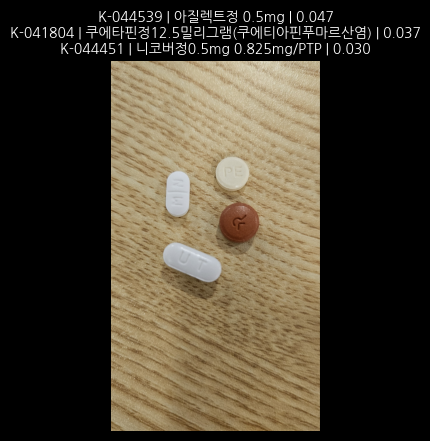

이미지: C:/project_sep/my_pill/original/test1.jpg
  K-044539 | 아질렉트정 0.5mg | 0.047
  K-041804 | 쿠에타핀정12.5밀리그램(쿠에티아핀푸마르산염) | 0.037
  K-044451 | 니코버정0.5mg 0.825mg/PTP | 0.030


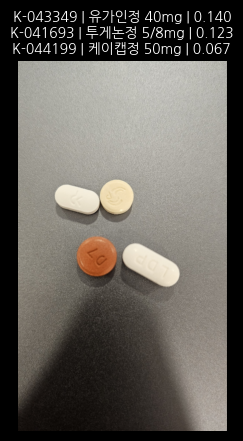

이미지: C:/project_sep/my_pill/original/test2.jpg
  K-043349 | 유가인정 40mg | 0.140
  K-041693 | 투게논정 5/8mg | 0.123
  K-044199 | 케이캡정 50mg | 0.067


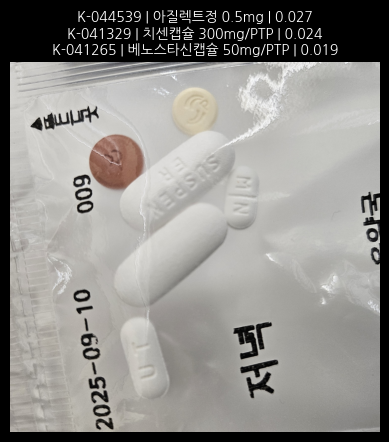

이미지: C:/project_sep/my_pill/original/test3.jpg
  K-044539 | 아질렉트정 0.5mg | 0.027
  K-041329 | 치센캡슐 300mg/PTP | 0.024
  K-041265 | 베노스타신캡슐 50mg/PTP | 0.019


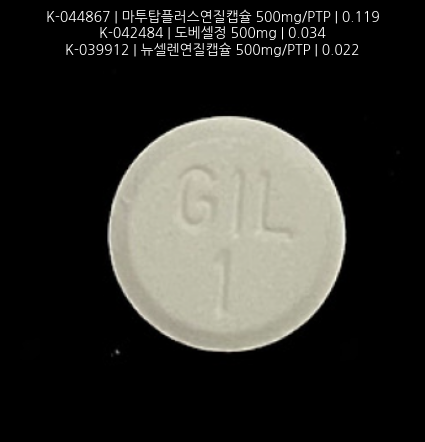

이미지: C:/project_sep/my_pill/original/image.png
  K-044867 | 마투탑플러스연질캡슐 500mg/PTP | 0.119
  K-042484 | 도베셀정 500mg | 0.034
  K-039912 | 뉴셀렌연질캡슐 500mg/PTP | 0.022


In [10]:
import koreanize_matplotlib

test_imgs = [
    r"C:/project_sep/my_pill/original/test1.jpg",
    r"C:/project_sep/my_pill/original/test2.jpg",
    r"C:/project_sep/my_pill/original/test3.jpg",
    r"C:/project_sep/my_pill/original/image.png",
]

for path in test_imgs:
    predict_and_show(path)